In [1]:
import os

import matplotlib.pyplot as plt
import typhon as ty

ty.plots.styles.use()

In [2]:
# BASEPATH = "/home/olemke/Hacking/uhh/arts/"
BASEPATH = "/Users/olemke/Hacking/git/arts/"
SUBPATH = "controlfiles/TestSpectroscopy."
SUBDIR_RELDEB = "cmake-build-relwithdebinfo"
SUBDIR_RELEASE = "cmake-build-release"
f_grid = ty.arts.xml.load(os.path.join(BASEPATH, SUBDIR_RELDEB, SUBPATH + "f_grid.xml"))

In [3]:
typ = [
    "y",
    "y-ds0",
    "y-df0",
    "y-dAIR-G0-X0",
    "y-dAIR-G0-X1",
    "y-dAIR-D0-X0",
    "y-dAIR-D0-X1",
    "y-dAIR-G2-X0",
    "y-dAIR-G2-X1",
    "y-dAIR-D2-X0",
    "y-dAIR-D2-X1",
    "y-dAIR-FVC-X0",
    "y-dAIR-FVC-X1",
    "y-dAIR-ETA-X0",
    "y-dAIR-ETA-X1",
    "y-dAIR-Y-X0",
    "y-dAIR-Y-X1",
    "y-dAIR-Y-X2",
    "y-dAIR-G-X0",
    "y-dAIR-G-X1",
    "y-dAIR-G-X2",
    "y-dAIR-DV-X0",
    "y-dAIR-DV-X1",
    "y-dAIR-DV-X2",
]
print(len(typ))

24


# RelWithDebInfo vs. Release

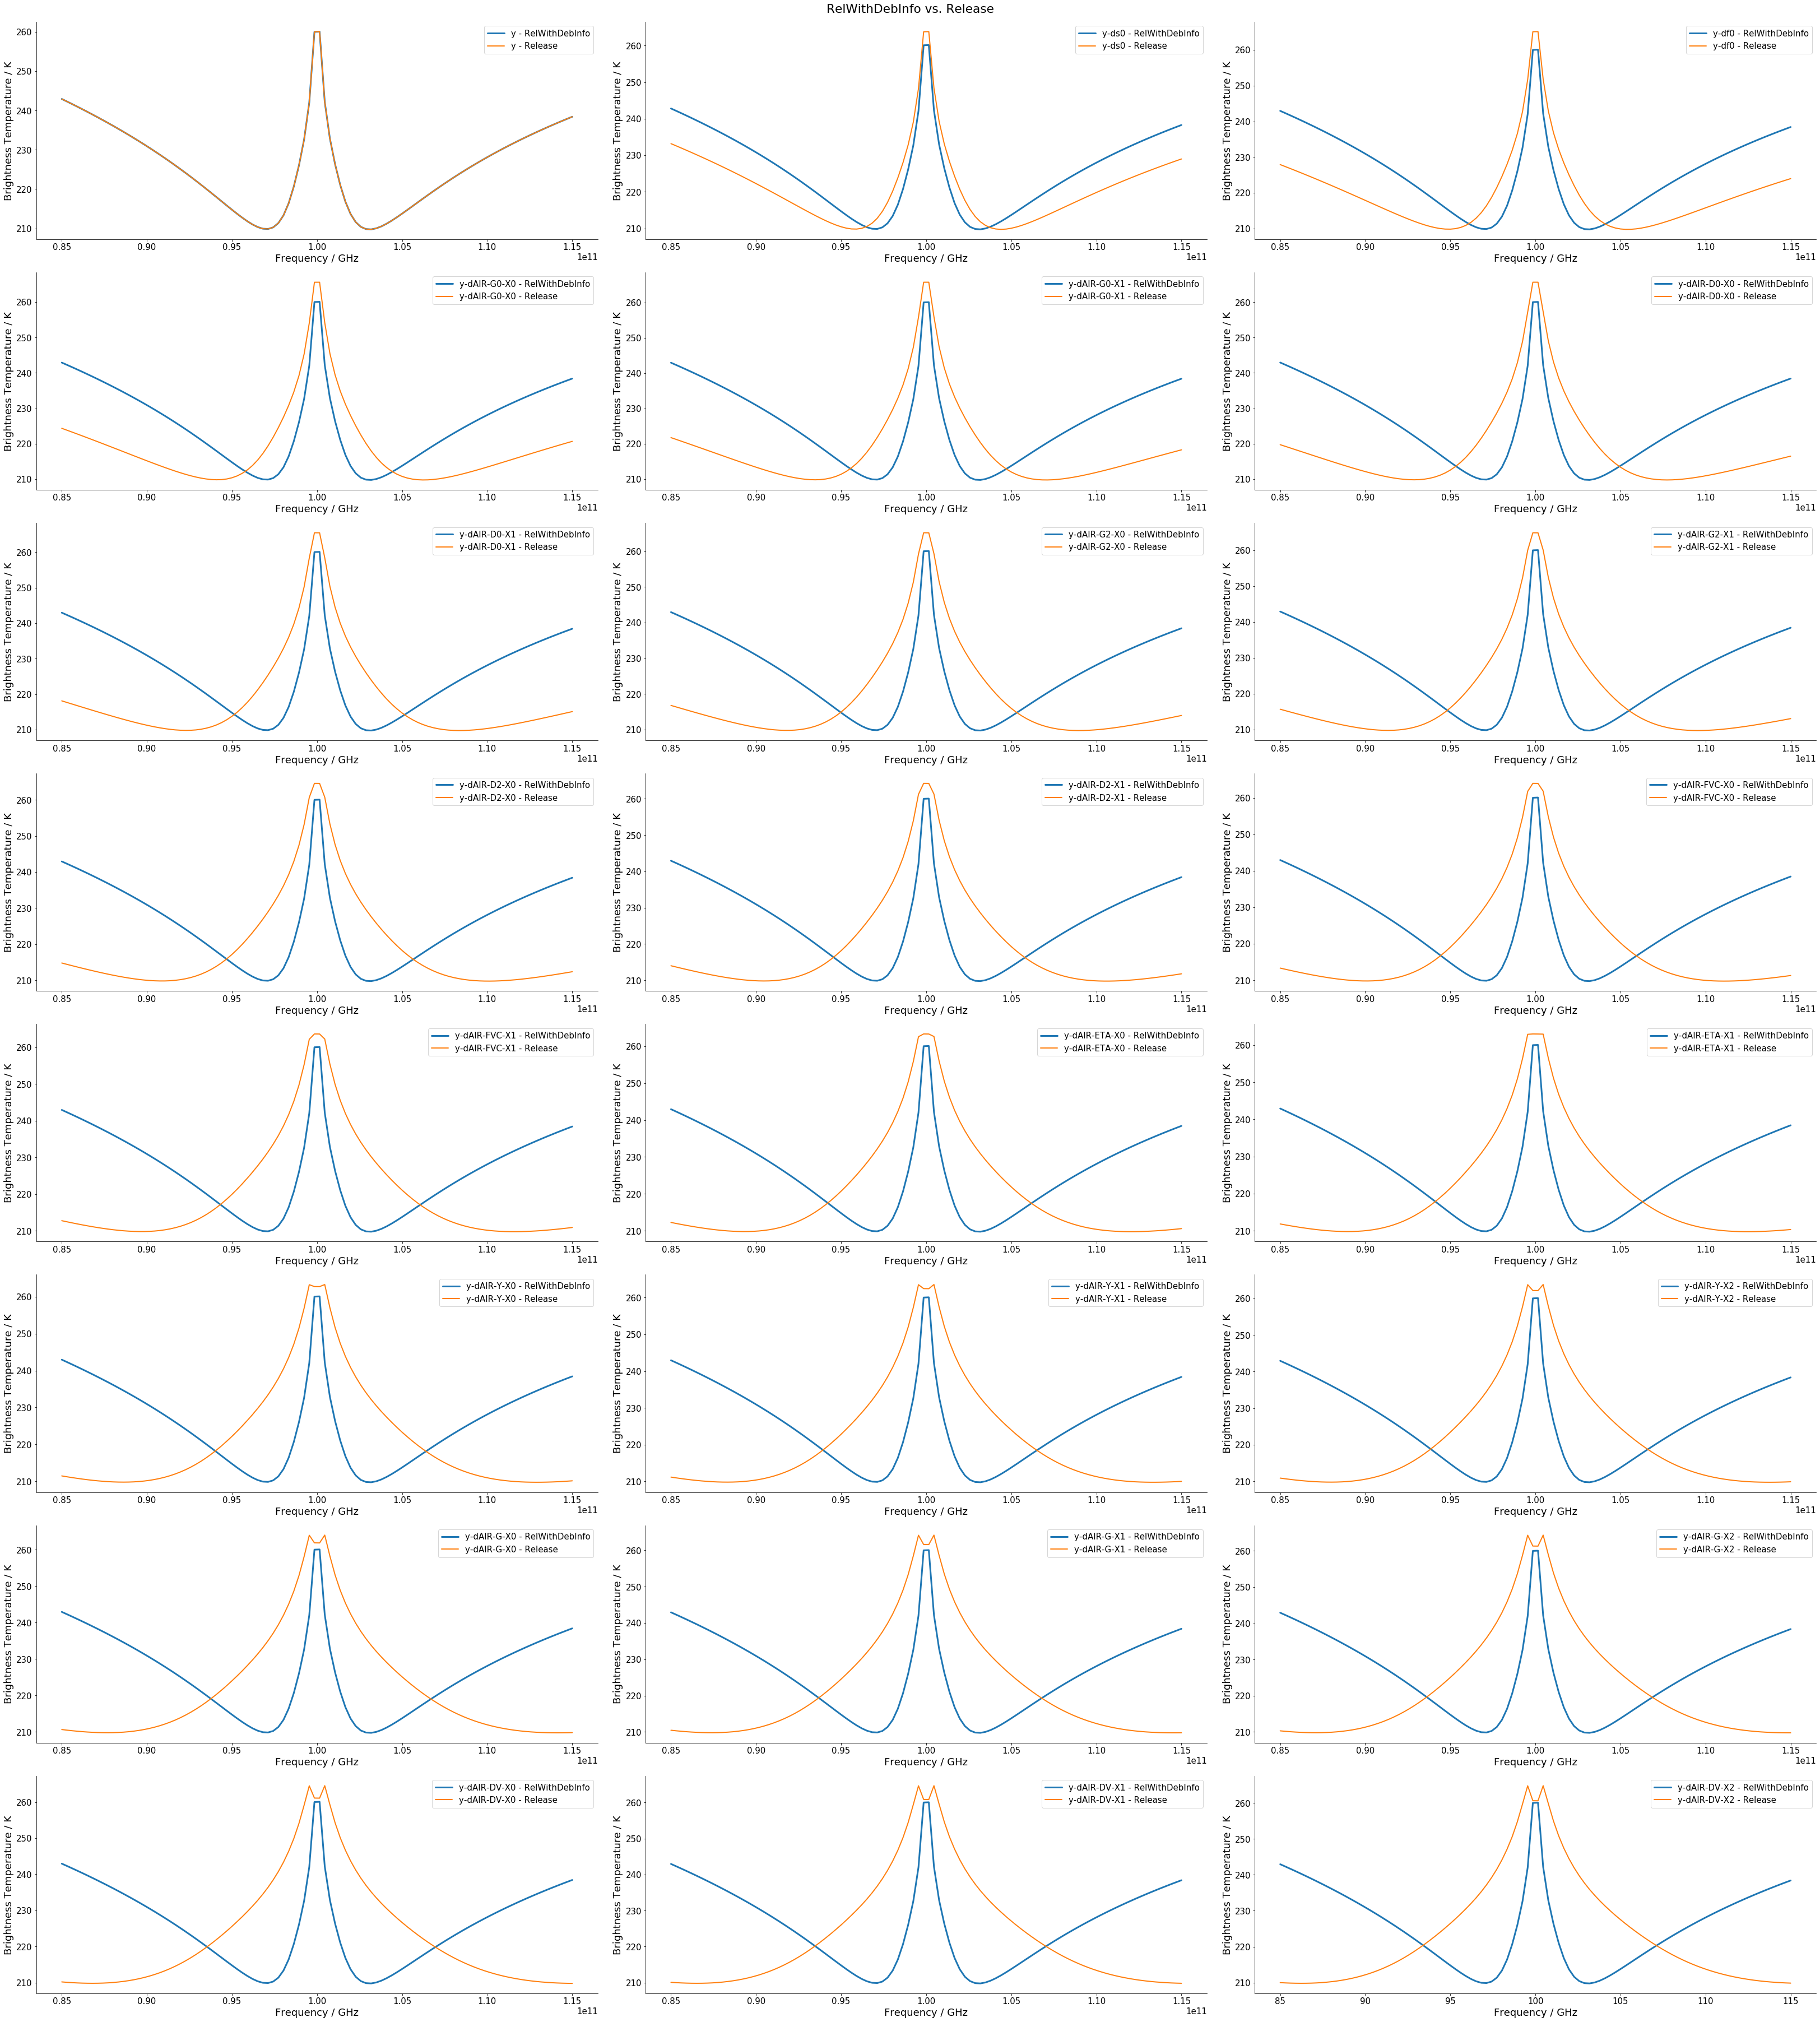

In [4]:
fig, axes = plt.subplots(8, 3, figsize=(45, 50), constrained_layout=True)
fig.suptitle("RelWithDebInfo vs. Release")
for t, ax in zip(typ, axes.ravel()):
    y1 = ty.arts.xml.load(os.path.join(BASEPATH, SUBDIR_RELDEB, SUBPATH + t + ".xml"))
    y2 = ty.arts.xml.load(os.path.join(BASEPATH, SUBDIR_RELEASE, SUBPATH + t + ".xml"))

    ax.plot(f_grid, y1, label=t + " - RelWithDebInfo", lw=3)
    ax.plot(f_grid, y2, label=t + " - Release")
    ty.plots.set_xaxis_formatter(ty.plots.formatter.ScalingFormatter(scaling=1e9))
    ax.set_ylabel("Brightness Temperature / K")
    ax.set_xlabel("Frequency / GHz")
    ax.legend()
    del y1
    del y2

fig.savefig("compare-reldeb-release.pdf")

# RelWithDebInfo y vs. Pertubations

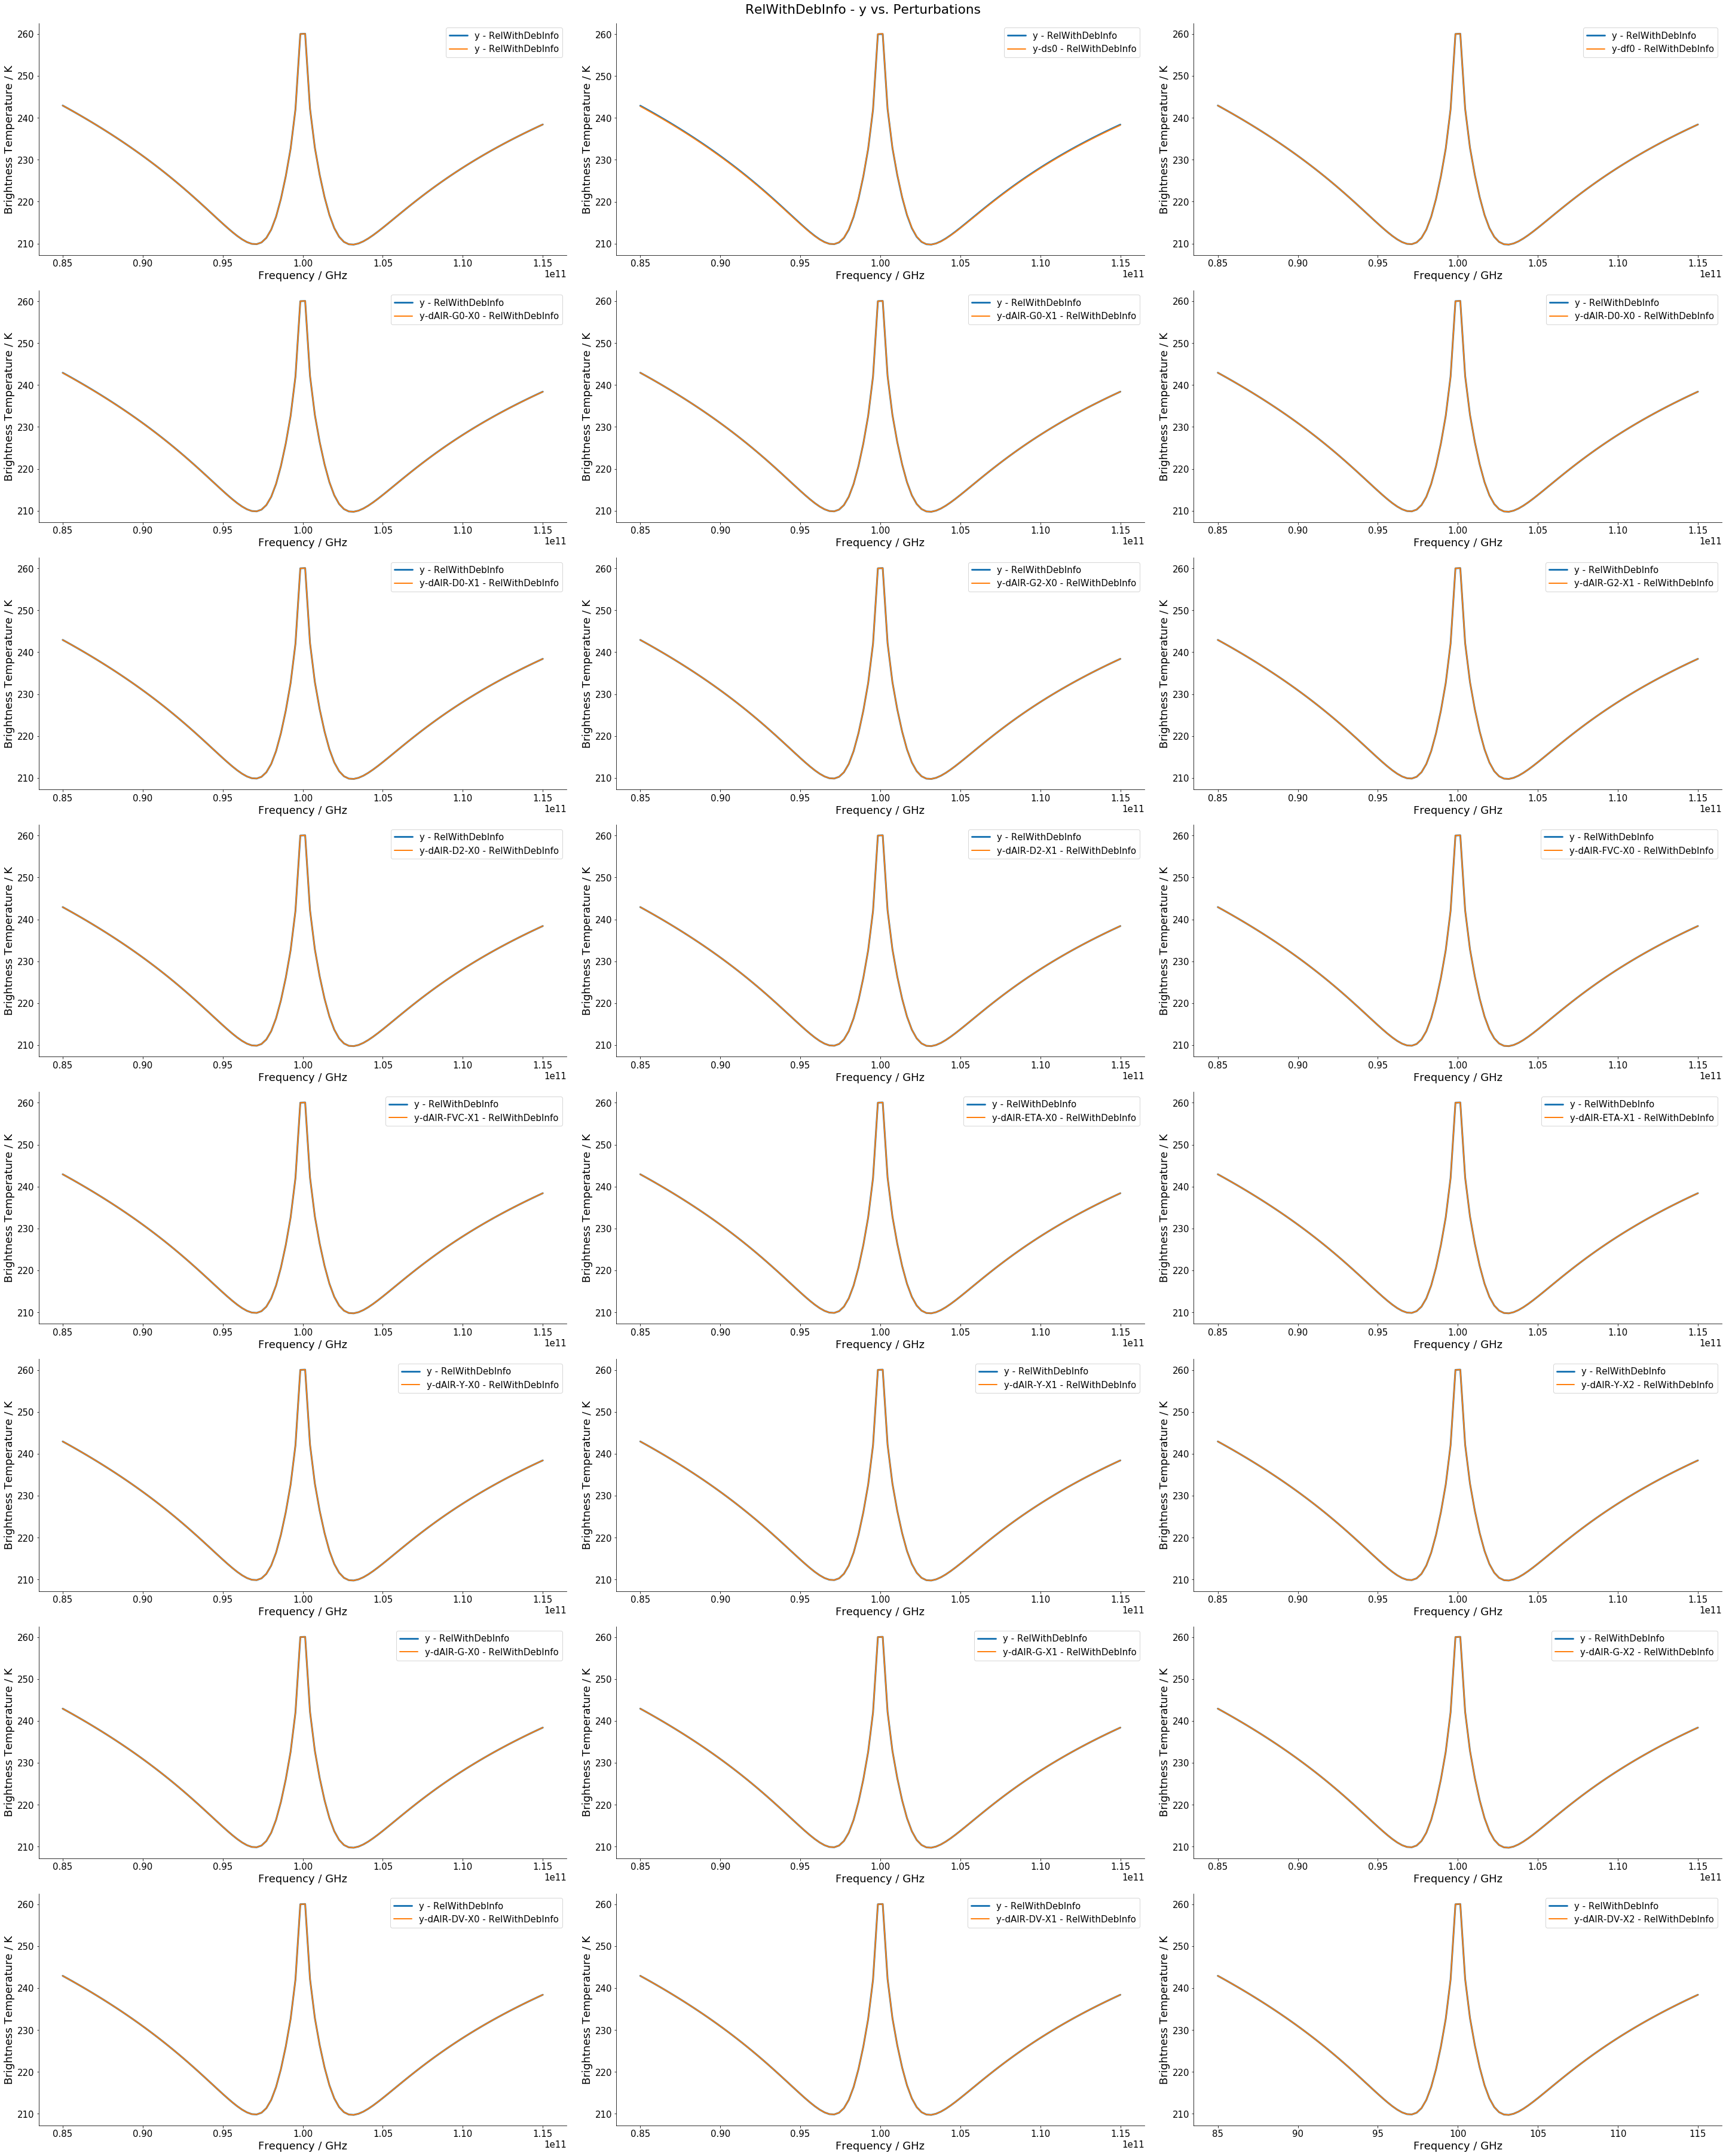

In [5]:
fig, axes = plt.subplots(8, 3, figsize=(40, 50), constrained_layout=True)
fig.suptitle("RelWithDebInfo - y vs. Perturbations")
for t, ax in zip(typ, axes.ravel()):
    y1 = ty.arts.xml.load(os.path.join(BASEPATH, SUBDIR_RELDEB, SUBPATH + "y" + ".xml"))
    y2 = ty.arts.xml.load(os.path.join(BASEPATH, SUBDIR_RELDEB, SUBPATH + t + ".xml"))

    ax.plot(f_grid, y1, label="y - RelWithDebInfo", lw=3)
    ax.plot(f_grid, y2, label=t + " - RelWithDebInfo")
    ty.plots.set_xaxis_formatter(ty.plots.formatter.ScalingFormatter(scaling=1e9))
    ax.set_ylabel("Brightness Temperature / K")
    ax.set_xlabel("Frequency / GHz")
    ax.legend()
    del y1
    del y2

fig.savefig("compare-reldeb-y.pdf")

# Release y vs. Perturbations

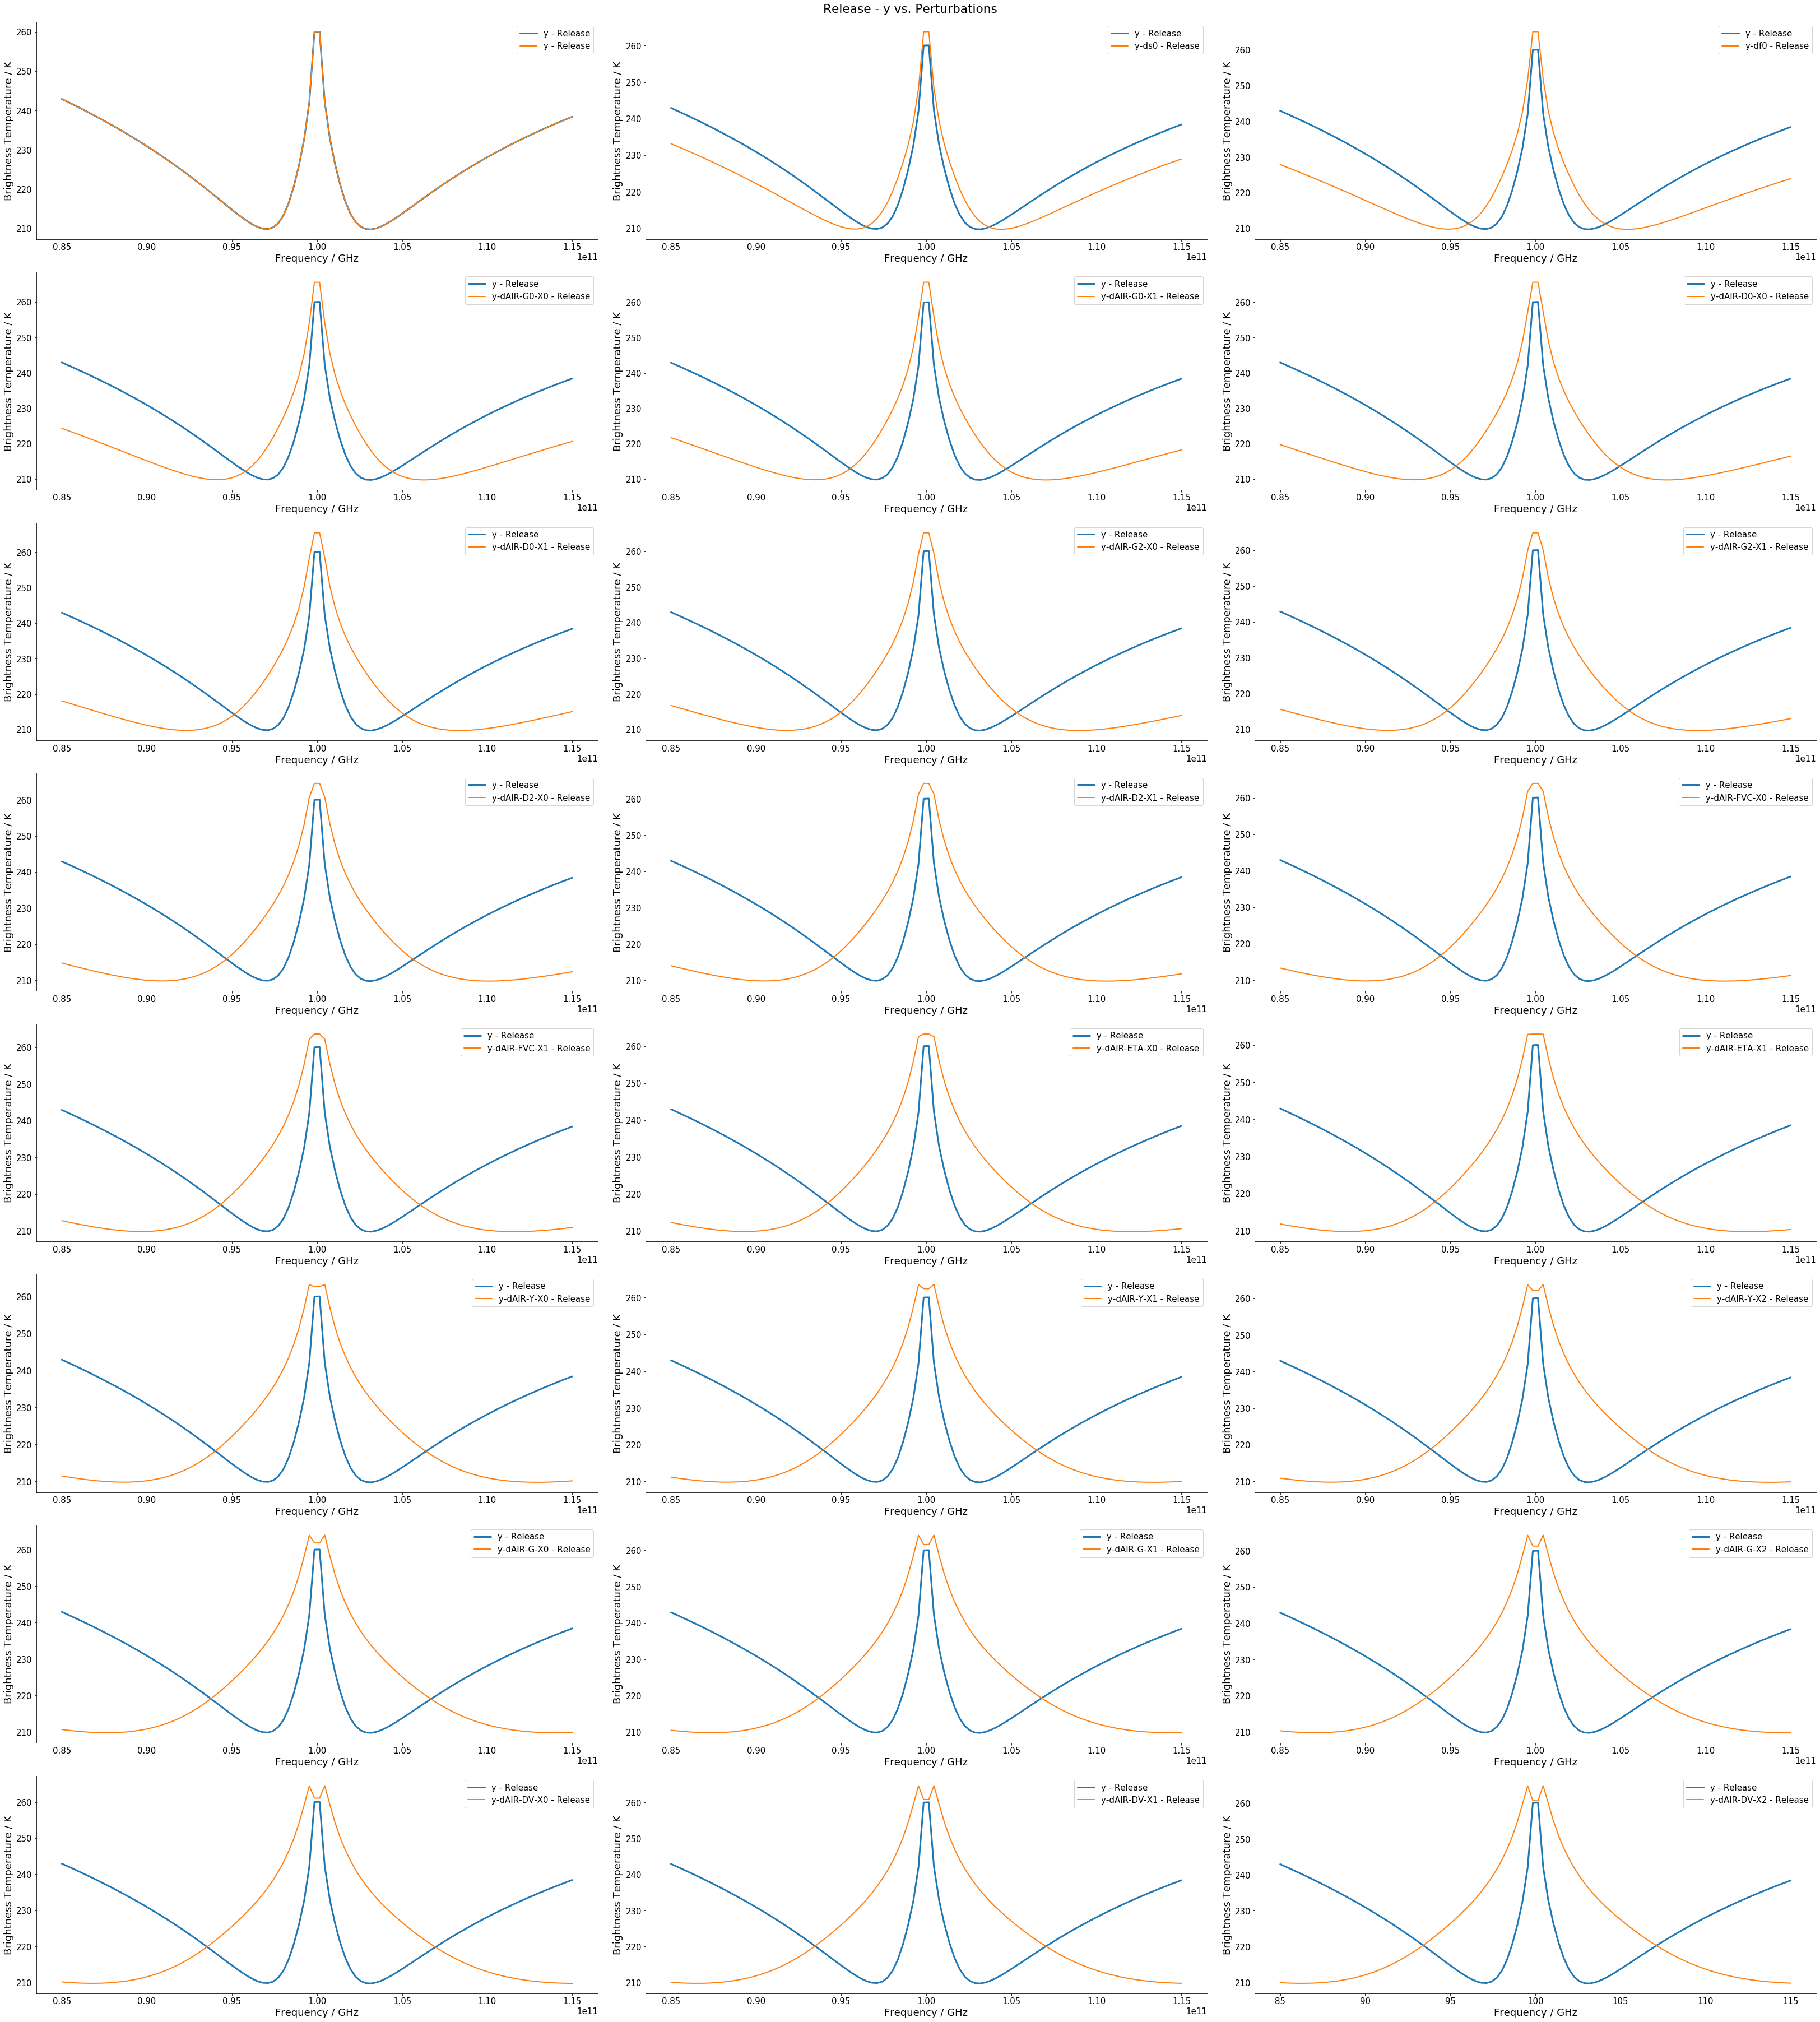

In [6]:
fig, axes = plt.subplots(8, 3, figsize=(45, 50), constrained_layout=True)
fig.suptitle("Release - y vs. Perturbations")
for t, ax in zip(typ, axes.ravel()):
    y1 = ty.arts.xml.load(os.path.join(BASEPATH, SUBDIR_RELEASE, SUBPATH + "y" + ".xml"))
    y2 = ty.arts.xml.load(os.path.join(BASEPATH, SUBDIR_RELEASE, SUBPATH + t + ".xml"))

    ax.plot(f_grid, y1, label="y - Release", lw=3)
    ax.plot(f_grid, y2, label=t + " - Release")
    ty.plots.set_xaxis_formatter(ty.plots.formatter.ScalingFormatter(scaling=1e9))
    ax.set_ylabel("Brightness Temperature / K")
    ax.set_xlabel("Frequency / GHz")
    ax.legend()
    del y1
    del y2

fig.savefig("compare-release-y.pdf")